# Calculate params for transitions specific to subtype 
- Compute subtype parameters

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap  

In [2]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Clustering using  UMAP fitted on partial data of FN

In [3]:
# fit UMAP to partial fn data
df_fn_comm_par= reader.data_read_bz2('results/comm_umap_results/pca_part_df_fn')
df_fn_comm_full=reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')
umap_model = umap.UMAP(n_neighbors=5,n_components=2,random_state=42)
# removing NaN if any 
df_fn_comm_par.dropna(inplace=True)

# comment out after finalised
df_combined= pd.concat([df_fn_comm_full,df_fn_comm_par],axis = 0)

_reducer = umap_model.fit(df_fn_comm_par.values)

# transforming using reducer
embedding_full = _reducer.transform(df_fn_comm_full.values)
embedding_part = _reducer.transform(df_fn_comm_par.values)
whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)
    
# finding reference centroids
kmeans_ref=KMeans(n_clusters=5, random_state=42).fit(whole_embedding)
ref_labels = kmeans_ref.labels_
ref_centroids = kmeans_ref.cluster_centers_


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Store whole embedding data and full embedding data in results so as to use in figure  

In [4]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

In [5]:
we_labels=assign_clusters(whole_embedding, ref_centroids)

In [14]:
fig_4a_data={'we':whole_embedding,'fe':embedding_full,'lbl':we_labels}
reader.data_dump_pkl('results/figures/fig4a_data.pkl',fig_4a_data)

Use main network reducer to transform every network

In [6]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))

# to store all networks UMAP transformed embeddings
embeddings=[]

# to store full embeddings
full_embeddings = []

# to store partial embeddings
part_embeddings = []

for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    
    em_full = _reducer.transform(df_full.values)
    em_part = _reducer.transform(df_part.values)
    em_whole = np.concatenate((em_full,em_part),axis=0)

    full_embeddings.append(em_full)
    part_embeddings.append(em_part)
    embeddings.append(em_whole)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

Instead of refitting Kmeans, clustering with nearest centroid so that cluster labels remains consistent throughout

In [7]:
def assign_clusters(embedding, centroids):
    return pairwise_distances_argmin(embedding, centroids)

For notebook 'Analyse Random Forest Cluster.ipynb', getting only labels for partial embeddings

In [6]:
part_nw_labels=[assign_clusters(embed,ref_centroids) for embed in part_embeddings]

In [7]:
full_nw_labels=[assign_clusters(embed,ref_centroids) for embed in full_embeddings]

In [7]:
reader.data_dump_pkl('raw/part_cluster_label.pkl',{'part_embeddings':part_embeddings,'label':part_nw_labels})

In [8]:

# list of labels for each network embedding
network_labels = [assign_clusters(embed, ref_centroids) for embed in embeddings]

Save data for notebook Random Forest classifier to see which community participates in our cluster subtypes more

In [14]:
reader.data_dump_pkl('raw/cluster_label.pkl',{'embeddings':embeddings,'label':network_labels})

Define a consistent colormap for 5 clusters

In [9]:
colors = {0: "green", 1: "red", 2: "C0",3:"orange",4:"purple"}

Plot clusterisation of all networks  
- Use this figure in supplementary for fig4a

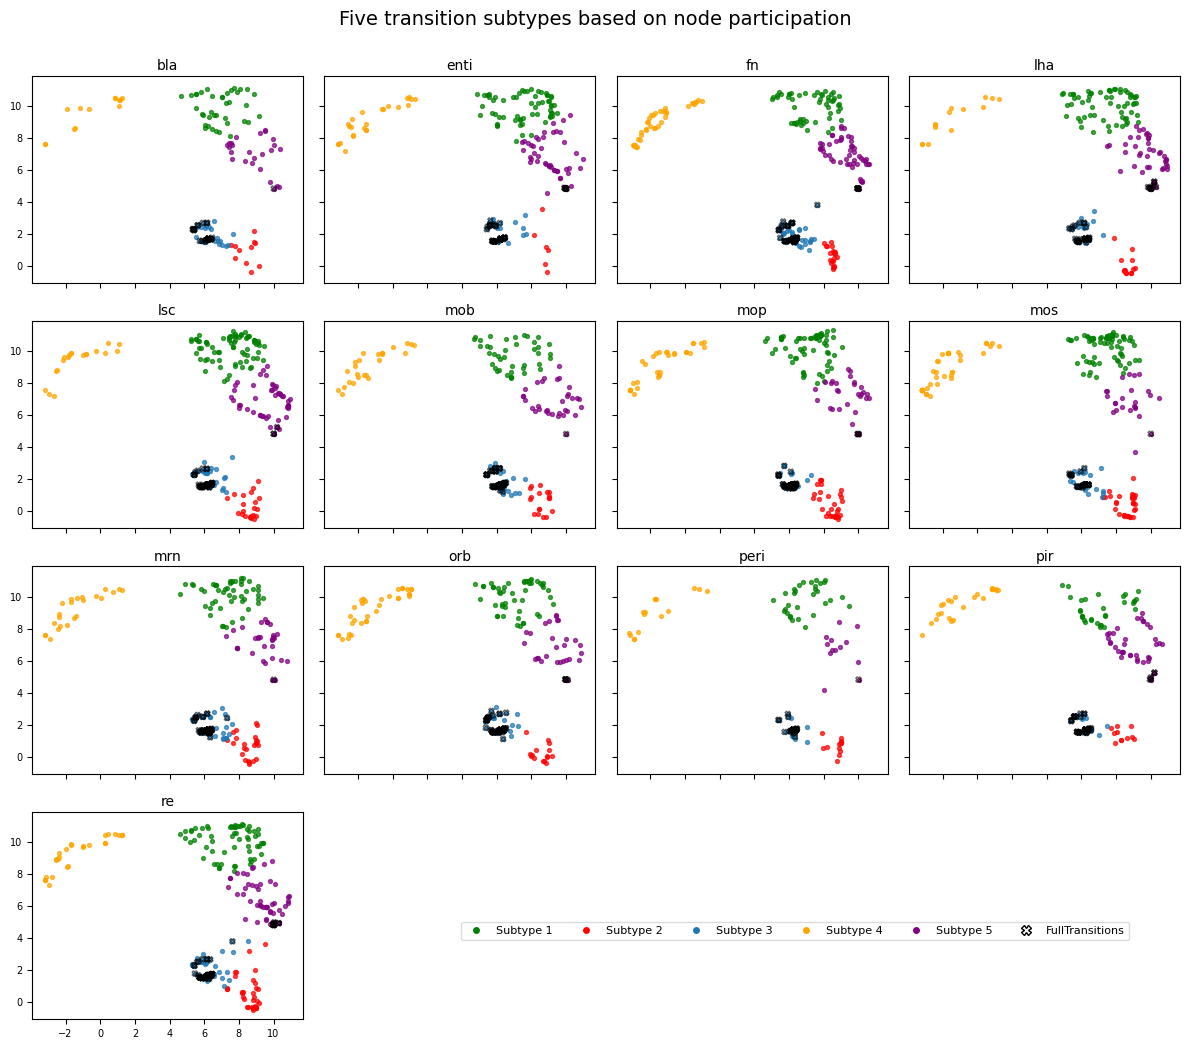

In [10]:
# supplementary 4.1
n_networks = len(embeddings)
n_cols = 4  # number of plots per row
n_rows = 4

# Standard A4 Landscape dimensions in inches: 11.69 x 8.27
# (Use figsize=(8.27, 11.69) if you prefer Portrait orientation)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (embed, labels, ax, f_embed) in enumerate(zip(embeddings, network_labels, axes, full_embeddings)):
    for cluster_id in np.unique(labels):
        cluster_points = embed[labels == cluster_id]
        # Scaled down marker size for A4 (from 60 to 12)
        ax.scatter(cluster_points[:,0], cluster_points[:,1],
                   c=colors[cluster_id], s=8, alpha=0.7)
        
    # Scaled down full embedding marker size (from 120 to 30)
    ax.scatter(f_embed[:,0], f_embed[:,1], s=15, marker='X', facecolors='none', edgecolors='k', alpha=0.6)

    # Subplot Titles (Scaled down to 10pt)
    network_name = Path(file_full[i]).stem.rsplit("_", 1)[-1]
    ax.set_title(f"{network_name}", fontsize=10, pad=4)
    
    # Tick Labels (Scaled down to 7pt)
    ax.tick_params(axis='both', labelsize=7)

# Hide unused axes if networks < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# Main Figure Title: Scaled down to 14pt (bold) for A4 paper size
fig.suptitle("Five transition subtypes based on node participation", fontsize=14, y=0.93)

legend_handles = []

legend_handles = []

for cluster_id in sorted(colors.keys()):
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=colors[cluster_id], 
               markersize=6, label=f'Subtype {cluster_id + 1}')
    )
legend_handles.append(
    Line2D([0], [0], marker='X', color='w', 
           markerfacecolor='none', markeredgecolor='k', 
           markersize=7, label='FullTransitions')
)
fig.legend(
    handles=legend_handles,
    loc='lower right',
    bbox_to_anchor=(0.95, 0.15), 
    ncol=len(legend_handles),  # Dynamically sets columns to make it landscape
    fontsize=8,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)
# ---------------------------------------------------------

plt.tight_layout(rect=[0, 0.06, 1, 0.93], h_pad=1.2, w_pad=1.2)

Find the ratio of points in a specific cluster to all the points in the partial network

In [11]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_cluster_count_ratio(df_par,network):

    # removing NaN if any 
    df_par.dropna(inplace=True)

    embedding_part = _reducer.transform(df_par.values)
    part_network_labels = assign_clusters(embedding_part,ref_centroids)
    # print(len(part_network_labels))

    # Assigning cluster labels to data points

    df_embed = pd.DataFrame(embedding_part)

    df_embed['cluster'] = part_network_labels

    df_count = df_embed.groupby('cluster').count()
    cluster_count = df_count[0]
    # print(cluster_count)
    total_count = df_count.sum()[0]
    # print(total_count)
    ratio=cluster_count/total_count
    ratio=ratio.to_frame()
    ratio.columns=[network]
    return ratio


In [12]:
df_cluster_count = pd.DataFrame()
for f_part in file_part:
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_part.dropna(inplace=True)
    # print(f_part)
    data_part = compute_cluster_count_ratio(df_part,f_part.split('_')[-1])
    df_cluster_count=pd.concat([df_cluster_count,data_part],axis=1)
df_cluster_count

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.355140,0.410596,0.284946,0.450000,0.401070,0.310606,0.390244,0.370968,0.344595,0.360294,0.397436,0.290909,0.315
1,0.102804,0.039735,0.112903,0.092857,0.117647,0.136364,0.182927,0.177419,0.162162,0.110294,0.166667,0.100000,0.165
2,0.196262,0.086093,0.129032,0.085714,0.122995,0.121212,0.054878,0.086022,0.128378,0.080882,0.076923,0.072727,0.140
3,0.121495,0.158940,0.204301,0.100000,0.101604,0.189394,0.207317,0.236559,0.155405,0.250000,0.205128,0.218182,0.135
4,0.224299,0.304636,0.268817,0.271429,0.256684,0.242424,0.164634,0.129032,0.209459,0.198529,0.153846,0.318182,0.245


Save above dataframe for data of fig4B plot  
- results/figures/fig4b_data.pkl

In [ ]:
# df_cluster_count.to_pickle('../../data/results/figures/fig4b_data.pkl',compression='bz2')

Text(0, 0.5, 'ratio')

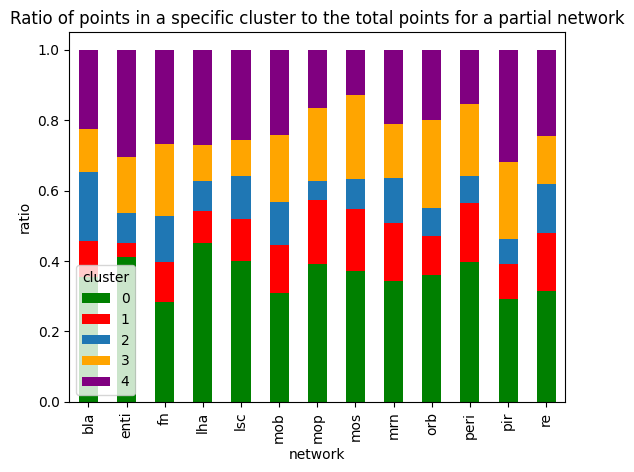

In [13]:

df_cluster_count.T.plot(kind='bar',color=colors, stacked=True)
plt.title('Ratio of points in a specific cluster to the total points for a partial network')
plt.xlabel('network')
plt.ylabel('ratio')

Find ratio of full to partial in a given cluster for a specific network

In [14]:
# df_par= reader.data_read_bz2('raw/workstation/pca_results/pca_part_df_fn')
# df_full=reader.data_read_bz2('raw/workstation/pca_results/pca_full_df_fn')

def compute_full_part_ratio(df_full,df_par,network):
    expected_clusters=[0,1,2,3,4]
    df_par.dropna(inplace=True)
    df_combined = pd.concat([df_full,df_par],axis=0)

    embedding_full=_reducer.transform(df_full.values)
    embedding_part = _reducer.transform(df_par.values)

    whole_embedding = np.concatenate((embedding_full, embedding_part), axis=0)

    # assign cluster labels
    whole_cluster_labels = assign_clusters(whole_embedding,ref_centroids)

    df_embed = pd.DataFrame(whole_embedding)
    df_embed['cluster']=whole_cluster_labels

    df_full_cluster = df_embed.iloc[0:df_full.shape[0]]
    df_full_cluster_count = df_full_cluster.groupby('cluster').count()
    fc_count = df_full_cluster_count[0].to_frame()
    fc_count=fc_count.reindex(expected_clusters,fill_value=0)
    # print(fc_count)


    df_part_cluster = df_embed.iloc[df_full.shape[0]:]
    df_part_cluster_count = df_part_cluster.groupby('cluster').count()
    fp_count = df_part_cluster_count[0].to_frame()
    fp_count=fp_count.reindex(expected_clusters,fill_value=0)
    # print(fp_count)

    ratio = (fc_count/fp_count) # ratio of full to partial
    ratio_full_tot =fc_count/(fc_count+fp_count) # ratio of full to total
    ratio.columns=[network]
    ratio_full_tot.columns=[network]
    # return ratio
    return {'ratio':ratio,'r_f_t':ratio_full_tot}
# ratio.columns=[network]



In [15]:
df_parfull_ratio = pd.DataFrame()
# dataframe for full to total ratio
df_fulltot_ratio=pd.DataFrame()
for f_full,f_part in zip(file_full,file_part):
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    # df_part.dropna(inplace=True)
    # print(f_part)
    data = compute_full_part_ratio(df_full,df_part,f_part.split('_')[-1])
    data_part=data['ratio']
    df_parfull_ratio=pd.concat([df_parfull_ratio,data_part],axis=1)

    data_full=data['r_f_t']
    df_fulltot_ratio=pd.concat([df_fulltot_ratio,data_full],axis=1)
df_parfull_ratio

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.380952,3.923077,4.041667,3.666667,4.086957,5.81250,7.666667,2.562500,4.105263,8.090909,7.666667,7.750000,2.964286
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.041667,0.130435,0.120000,0.289474,0.062500,0.03125,0.111111,0.041667,0.032258,0.185185,0.083333,0.142857,0.183673


plot full to partial ratio

Text(0, 0.5, 'ratio')

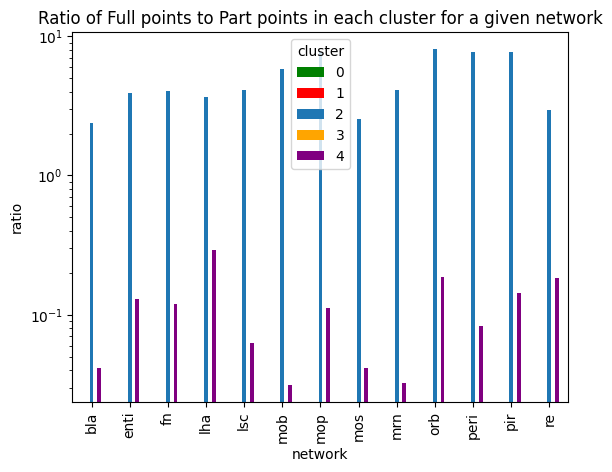

In [16]:

df_parfull_ratio.T.plot(kind='bar',color=colors,logy=True)
plt.title('Ratio of Full points to Part points in each cluster for a given network')
plt.xlabel('network')
plt.ylabel('ratio')

plot full to total ratio

In [32]:
df_fulltot_ratio['fn'].T

cluster
0    0.000000
1    0.000000
2    0.801653
3    0.000000
4    0.107143
Name: fn, dtype: float64

Save full to total

In [29]:
df_fulltot_ratio

,bla,enti,fn,lha,lsc,mob,mop,mos,mrn,orb,peri,pir,re
cluster,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
2,0.704225,0.796875,0.801653,0.785714,0.803419,0.853211,0.884615,0.719298,0.804124,0.89000,0.884615,0.885714,0.747748
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,0.040000,0.115385,0.107143,0.224490,0.058824,0.030303,0.100000,0.040000,0.031250,0.15625,0.076923,0.125000,0.155172


In [28]:
df_fulltot_ratio.to_pickle('../../data/results/figures/fig5a_data.pkl',compression='bz2')

Find cluster community wise mean

In [17]:

def compute_cluster_comm_partcptn(df_f,df_p,n):
    df_p.dropna(inplace=True)
    df_combined = pd.concat([df_f,df_p],axis=0)
    # print(df_f.shape)
    # print(df_p.shape)
    # print(df_combined.shape)

    df_combined['cluster']=network_labels[n]
    # print(df_combined.shape)

    # removing df_full rows from combined
    df_work=df_combined.iloc[df_f.shape[0]:,:]
    # print(df_work.shape)
    # df_work.head()

    # take average clusterwise for each column

    communities = list(df_work.columns[:-1])
    # print(communities)
    cluster_data = pd.DataFrame()
    for comm in communities:
        # print(comm)
        df_cluster = df_work.groupby('cluster')[comm].mean()
        cluster_data=pd.concat([cluster_data,df_cluster],axis=1)

    # Plot bar chart using cluster data
    # take avg of each cluster excluding hind
    # print(cluster_data)
    avg_0 = cluster_data.loc[0][:-1].mean()
    avg_1 = cluster_data.loc[1][:-1].mean()
    avg_2 = cluster_data.loc[2][:-1].mean()

    # comment when using 3 clusters only
    avg_3 = cluster_data.loc[3][:-1].mean()
    avg_4 = cluster_data.loc[4][:-1].mean()

    # Normalizing each cluster 
    c_0 = cluster_data.loc[0]/avg_0
    c_1 = cluster_data.loc[1]/avg_1
    c_2 = cluster_data.loc[2]/avg_2

    # comment when using 3 clusters
    c_3 = cluster_data.loc[3]/avg_3
    c_4 = cluster_data.loc[4]/avg_4

    # print(cluster_data.head(3))
    # Updating cluster data to plot
    cluster_data.loc[0]=c_0
    cluster_data.loc[1]=c_1
    cluster_data.loc[2]=c_2

    # comment when using 3 clusters
    cluster_data.loc[3]=c_3
    cluster_data.loc[4]=c_4
    
    # cluster_data.head(3)
    cluster_plot = cluster_data.copy()

    # cluster_plot.head()
    # print(cluster_plot)
    return cluster_plot
    



Supplementary 4.6

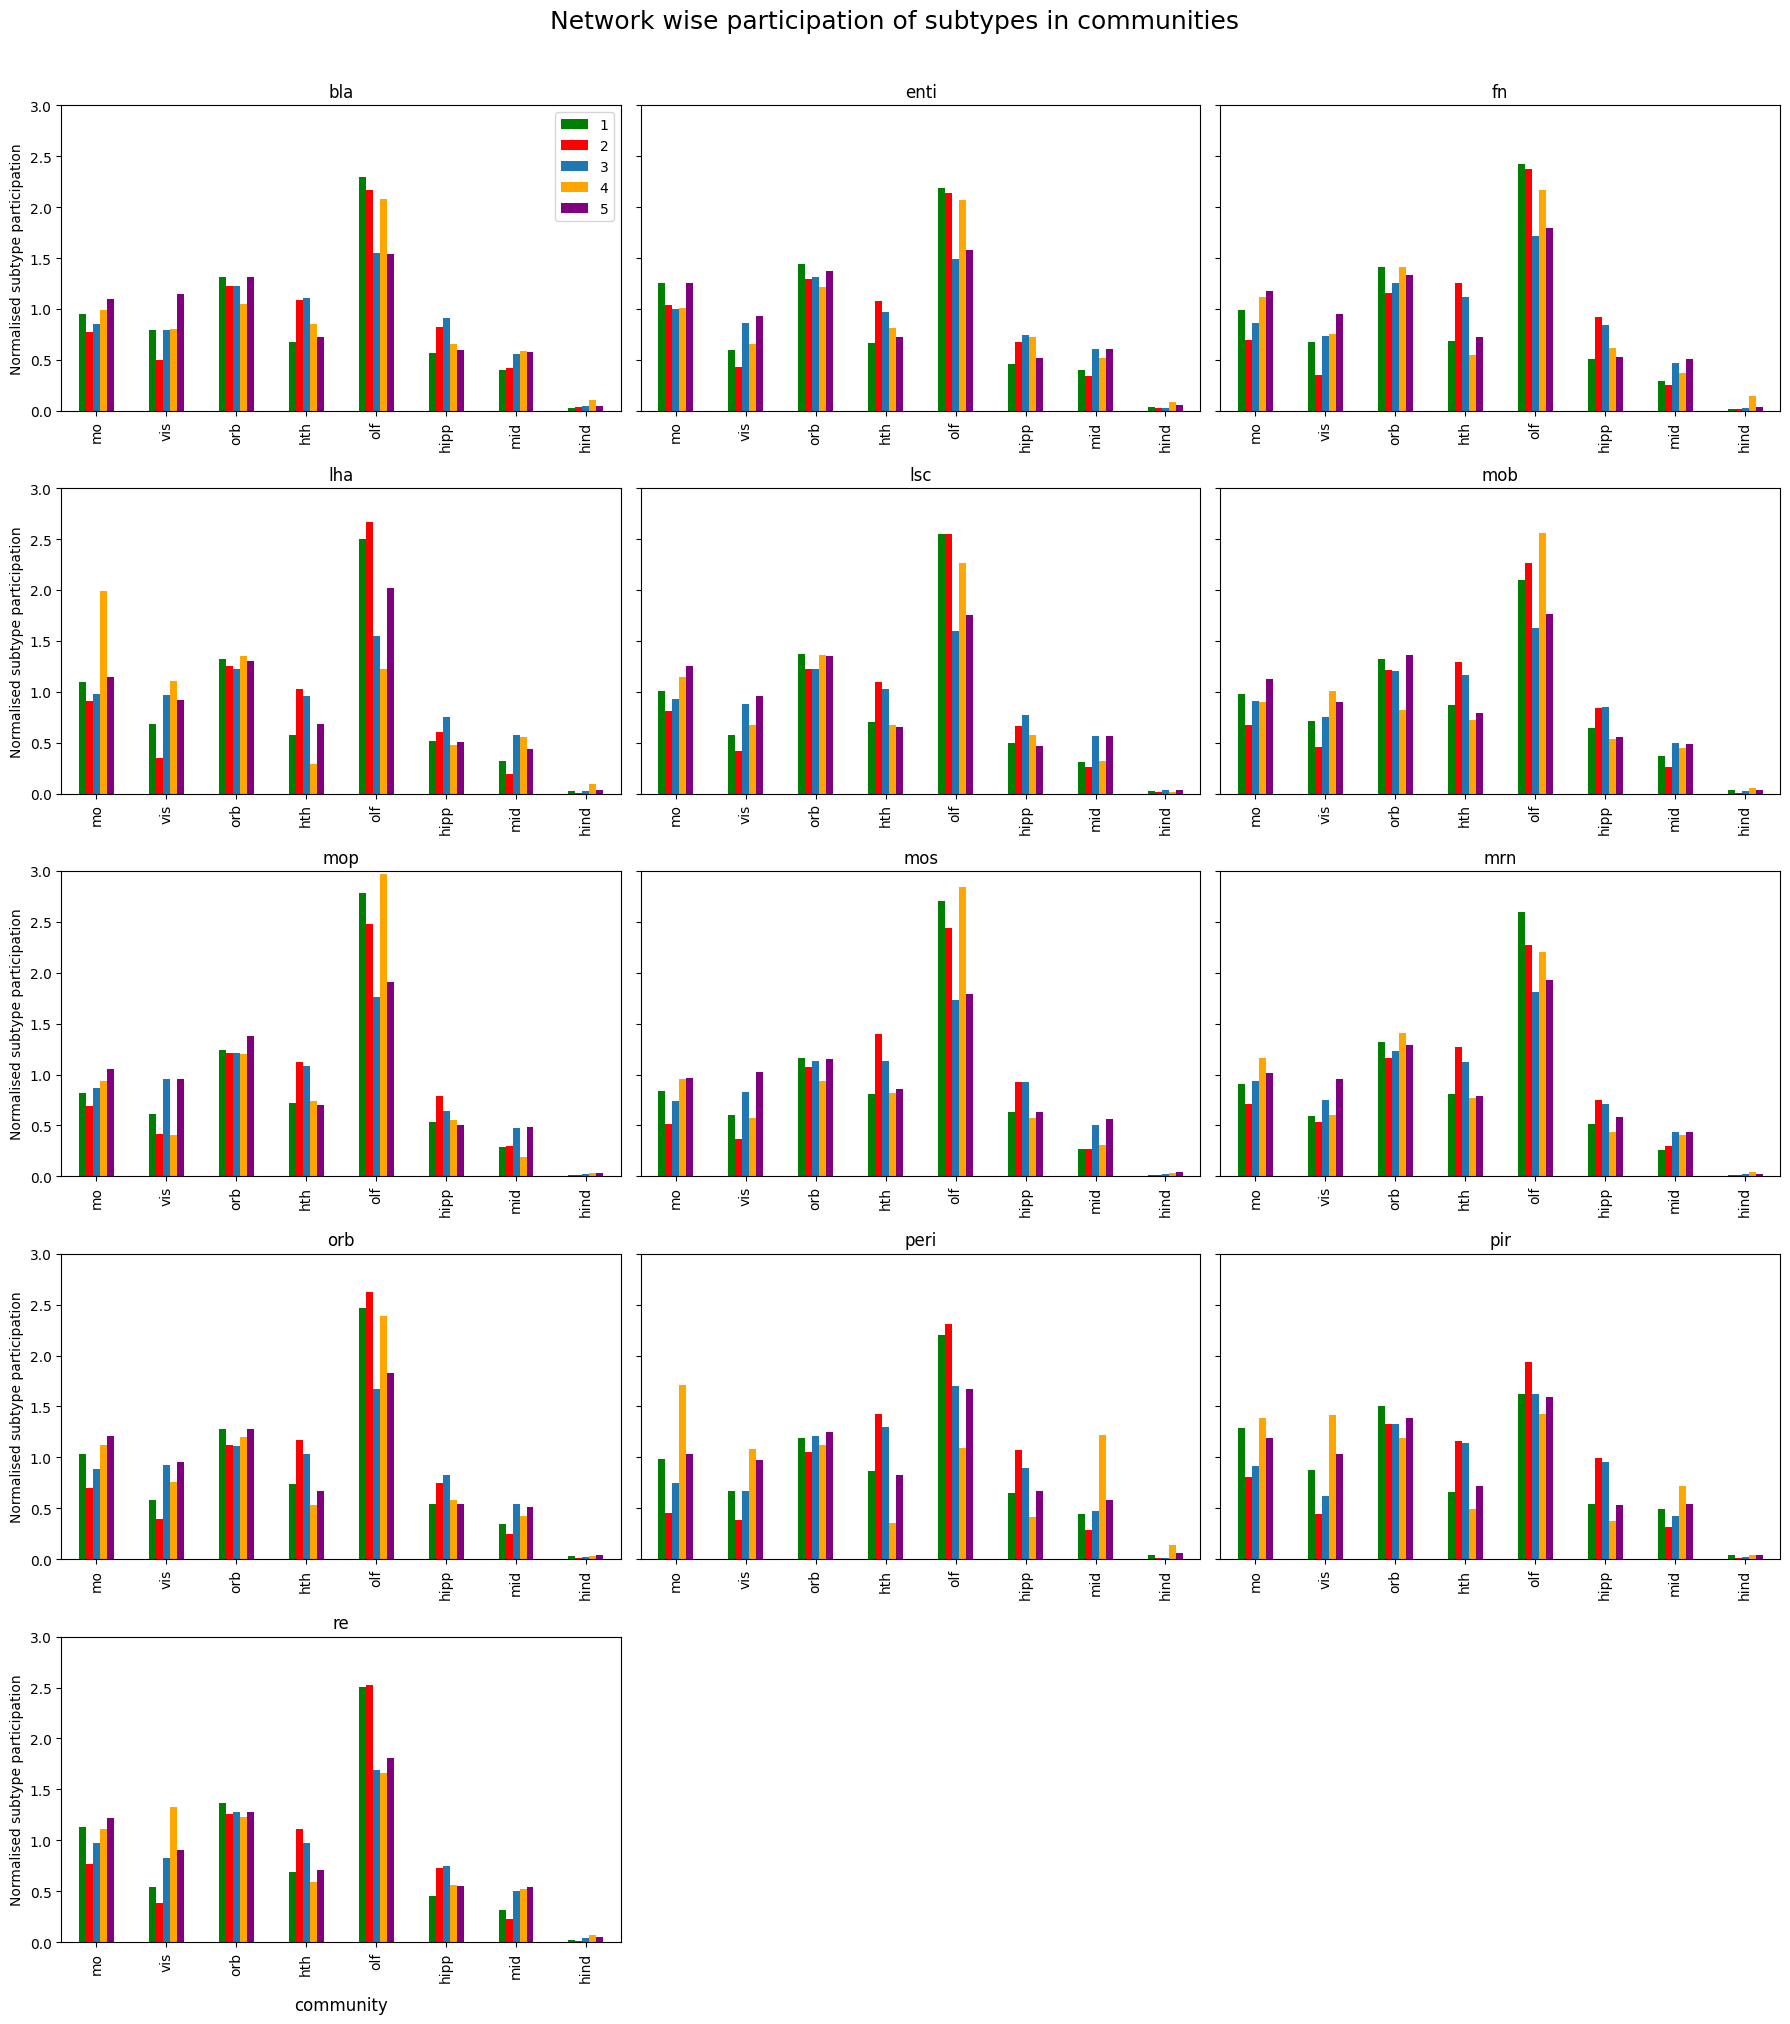

In [20]:
import math
import matplotlib.pyplot as plt
import pandas as pd

n_files = len(file_full)   # should be 13
n_cols = 3                 # number of columns you want
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

cluster_colors = {1: "green", 2: "red", 3: "C0", 4: "orange", 5: "purple"}
data_dict = {}

for n, (f_full, f_part, ax) in enumerate(zip(file_full, file_part, axes)):
    df_f = pd.read_pickle(f_full, compression='bz2')
    df_p = pd.read_pickle(f_part, compression='bz2')
    
    clusterData = compute_cluster_comm_partcptn(df_f, df_p, n)
    
    # set cluster labels explicitly
    clusterData.index = [1, 2, 3, 4, 5]
    
    # plot
    plot_obj = clusterData.T.plot(
        kind='bar',
        ax=ax,
        color=[cluster_colors.get(c, "gray") for c in clusterData.T.columns],
        legend=(n == 0)   # legend only for the first subplot
    )
    
    # Only set 'community' label on the very last valid file subplot
    if n == n_files - 1:
        ax.set_xlabel('community', fontsize=12, labelpad=10)
    else:
        ax.set_xlabel('')
        
    # Keep y-label and y-tick labels ONLY for the left-most plots (Column 0)
    if n % n_cols == 0:
        ax.set_ylabel('Normalised subtype participation')
    else:
        ax.set_ylabel('')          # Remove y-axis title string
        ax.set_yticklabels([])     # Remove y-tick text labels (numbers)

    ax.set_ylim(0, 3)
    ax.set_title(file_full[n].split('_')[-1])

    # flatten with MultiIndex labels
    labels = [(comm, clus) for comm in clusterData.index for clus in clusterData.columns]
    cl_data = pd.Series(clusterData.values.flatten(), index=pd.MultiIndex.from_tuples(labels))
    nw = file_full[n].split('_')[-1]
    data_dict[nw] = cl_data

# Hide unused subplots completely from the canvas
for ax in axes[n_files:]:
    ax.set_visible(False)

plt.suptitle('Network wise participation of subtypes in communities', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

do kmeans

In [70]:
kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clus_data_tf)

Using PCA

Text(0.5, 1.0, '13 x40 reduced to 13x2 using PCA')

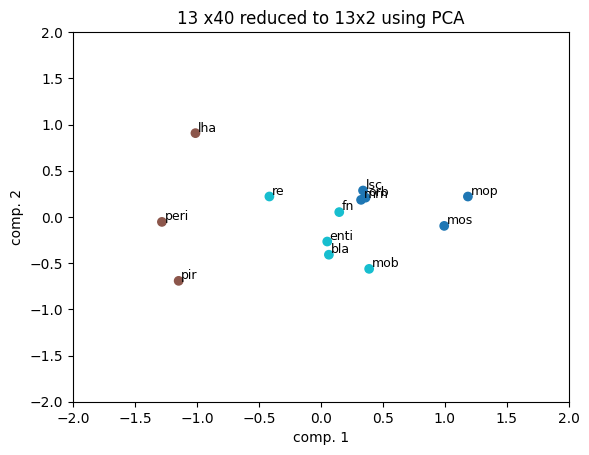

In [ ]:
from sklearn.decomposition import PCA
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(df_out.values)
clu_tf_pca=reducer_pca.transform(df_out.values)

kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)

plt.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10')
for i, label in enumerate(labels):
    plt.text(clu_tf_pca[i,0]+0.02, clu_tf_pca[i,1]+0.02, label, fontsize=9)

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.ylabel('comp. 2')
plt.xlabel('comp. 1')
plt.title('13 x40 reduced to 13x2 using PCA')

## Compute clusterwise params

Use this file which contains iteration number and the transition in it for every network  
Saved in 'results/comm_umap_results/part_full_comm_ind.pkl'

- Network based iteration number and index result
- Tuple index is row number of your 'trans x 8' file
- Tuple 1st element is iteration number
- Tuple 2nd element is the index number of the transition in that iteration

In [40]:
nw_itr= reader.data_read_pkl('results/comm_umap_results/part_full_comm_ind.pkl')

Peek inside above file

In [32]:
# nw_itr.keys()    
# ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
# nw_itr['bla'].keys()
# ['part_ind', 'full_ind']
# nw_itr['bla']['full_ind']    
# list of tuples

Define function which labels each transition by it's cluster  
INPUT: trans x 8, nw_itr, _reducer, ref_centroids  
OUTPUT:   Cluster indices i.e row index of trans x 8  

In [33]:
df_par= reader.data_read_bz2('results/comm_umap_results/pca_full_df_fn')

In [ ]:
def compute_cluster_indices(df,nw_itr,_reducer, ref_centroids, nw, trans_type):
    """Compute index of rows of df specific to a cluster

    Args:
        df (dataframe): number of transitions x 8 (Community wise participation for each transition)
        nw_itr (dict): Contains iteration number and the transition in it for all networks (Partial and Full transitions both)
        _reducer (UMAP): UMAP reduced on partial FN data
        ref_centroids (nd array): Centroids as per FN data after clustering
        nw (string): ['bla', 'enti', 'fn', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'orb', 'peri', 'pir', 're']
        trans_type (string): ['part_ind', 'full_ind']

    Returns:
        dictionary: keys: 'cluster_ind',''new_ind'
    """
    i_part=nw_itr[nw][trans_type].copy()
    # find NaN rows index of entries x 8 vector space
    nan_indices = df.index[df.isnull().any(axis=1)].tolist()

    # removing the NaN row
    if not nan_indices:
        pass
        new_ind=i_part
    else:
        # dropping NaN value
        df.dropna(inplace = True)
        # removing nan entries from nw_itr of given network
        
        for i in nan_indices:
            new_ind = [val for i, val in enumerate(i_part) if i not in nan_indices]

    

    embedding = _reducer.transform(df.values)
    network_labels = assign_clusters(embedding,ref_centroids)

    # assigning cluster labels to our 186 x2 vector space  
    df_embed = pd.DataFrame(embedding)
    df_embed['cluster'] = network_labels

    cluster_indices = {c: df_embed.index[df_embed['cluster'] == c].tolist() for c in df_embed['cluster'].unique()}
    
    return {'cluster_ind':cluster_indices,'nw_new':new_ind}



   

In [35]:
l=compute_cluster_indices(df_par,nw_itr,_reducer,ref_centroids,'fn','full_ind')


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [36]:
l['cluster_ind'].keys()

dict_keys([2, 4])

Define function which computes parameters clusterwise

In [ ]:
def compute_cluster_params(cluster_indices,new_ind,df_go,df_nc):
    """Computes cluster wise params and stores them in dict

    Args:
        cluster_indices (_type_): _description_
        new_ind (_type_): _description_
        df_go (_type_): _description_
        df_nc (_type_): _description_

    Returns:
        _type_: _description_
    """
    clus_params={}
    for i in list(l['cluster_ind'].keys()):

        # saving clusterwise params data
        fpt=[]
        st=[]
        cov=[]
        tt=[]
        for ind in cluster_indices[i]:
            

            # getting actual iteration number
            itrn = new_ind[ind]
            
            # compute params
            pts=algo_umap.compute_parameters(df_go[itrn[0]])
            fpt_list=algo.compute_fpt(pts['start_points'].copy(),pts['stop_points'].copy())[itrn[1]]
            fpt.append(fpt_list)
            st_list = algo.compute_sync(pts['start_points'].copy(),pts['stop_points'].copy())
            if itrn[1]  < len(st_list):
                # consider case when transition doesn't falls back
                st.append(st_list[itrn[1]])
            
            cov_list = comm_ops.compute_individual_coverage_nc(df_nc.loc[itrn[0]], df_go[itrn[0]])[itrn[1]]
            cov.append(cov_list)
            tt_list = algo_umap.compute_transition_time(df_go[itrn[0]],pts['start_points'].copy())[itrn[1]]
            tt.append(tt_list)

        clus_params[i]={'fpt':fpt,'st':st, 'cov':cov, 'tt':tt}
    return clus_params
        

In [ ]:
df_go = reader.data_read_bz2('raw/workstation/tes_fn_go.bz2')
df_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')

In [ ]:
f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

#### Compute for full params clusterwise

In [4]:
data_folder=Path('../../data/results/comm_umap_results/')
file_full=glob.glob(str(data_folder/'pca_full_df_*'))
file_part=glob.glob(str(data_folder/'pca_part_df_*'))



In [ ]:
data_folder = Path('../../data/raw/workstation')
file_go =glob.glob(str(data_folder/'tes_*_go.bz2'))
file_nc=glob.glob(str(data_folder/'tes_*_nc.bz2'))

In [ ]:
f_name = file_full[0]

In [ ]:
f_name.split('_')[-1]

'bla'

In [ ]:
for f_full,f_part,f_go,f_nc in zip(file_full,file_part,file_go,file_nc):
    nw=f_full.split('_')[-1]
    
    df_full=pd.read_pickle(f_full,compression='bz2')
    df_part=pd.read_pickle(f_part,compression='bz2')
    df_go=pd.read_pickle(f_go,compression='bz2')
    df_nc=pd.read_pickle(f_nc,compression='bz2')
    # computing full
    l=compute_cluster_indices(df_full,nw_itr,_reducer,ref_centroids,nw,'full_ind')
    f_full=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # save
    # reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/full_{nw}',f_full)


    #computing part
    l=compute_cluster_indices(df_part,nw_itr,_reducer,ref_centroids,nw,'part_ind')
    f_part=compute_cluster_params(l['cluster_ind'],l['nw_new'],df_go,df_nc)
    # reader.data_dump_pkl(f'results/comm_umap_results/comm_wise_params/part_{nw}',f_part)


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

...

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
this cell
this cell
this cell


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Folder where clusterwise params data is stored

In [3]:
data_folder = Path('../../data/results/comm_umap_results/comm_wise_params')
file_full = glob.glob(str(data_folder/'full_*'))
file_part = glob.glob(str(data_folder/'part_*'))



#### Fit st and fpt clusterwise

In [4]:
def fit_piecewiseLinear(data):
    intervals=data.copy()
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)
    # Fit piecewise linear with 3 segments
    x=intervals
    y=log_ccdf
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    # Predict
    y_hat = my_pwlf.predict(x)
    # comment out slopes and add to list if u need them
    slopes=my_pwlf.slopes

    return [x,y,y_hat,round(breaks[1]),slopes]

    
    # ax.scatter(x, y)
    # ax.plot(x, y_hat, 'r')
    # ax.set_ylabel("log P(T > t)")
    # ax.set_title(f"Log-CCDF {label} {round(breaks[1])} (2 fits)")
    # ax.legend()
    

Supplementary - Clusterwise only ST fit

Processed ST Fit for: bla
Processed ST Fit for: enti
Processed ST Fit for: fn
Processed ST Fit for: lha
Processed ST Fit for: lsc
Processed ST Fit for: mob
Processed ST Fit for: mop
Processed ST Fit for: mos
Processed ST Fit for: mrn
Processed ST Fit for: orb
Processed ST Fit for: peri
Processed ST Fit for: pir
Processed ST Fit for: re


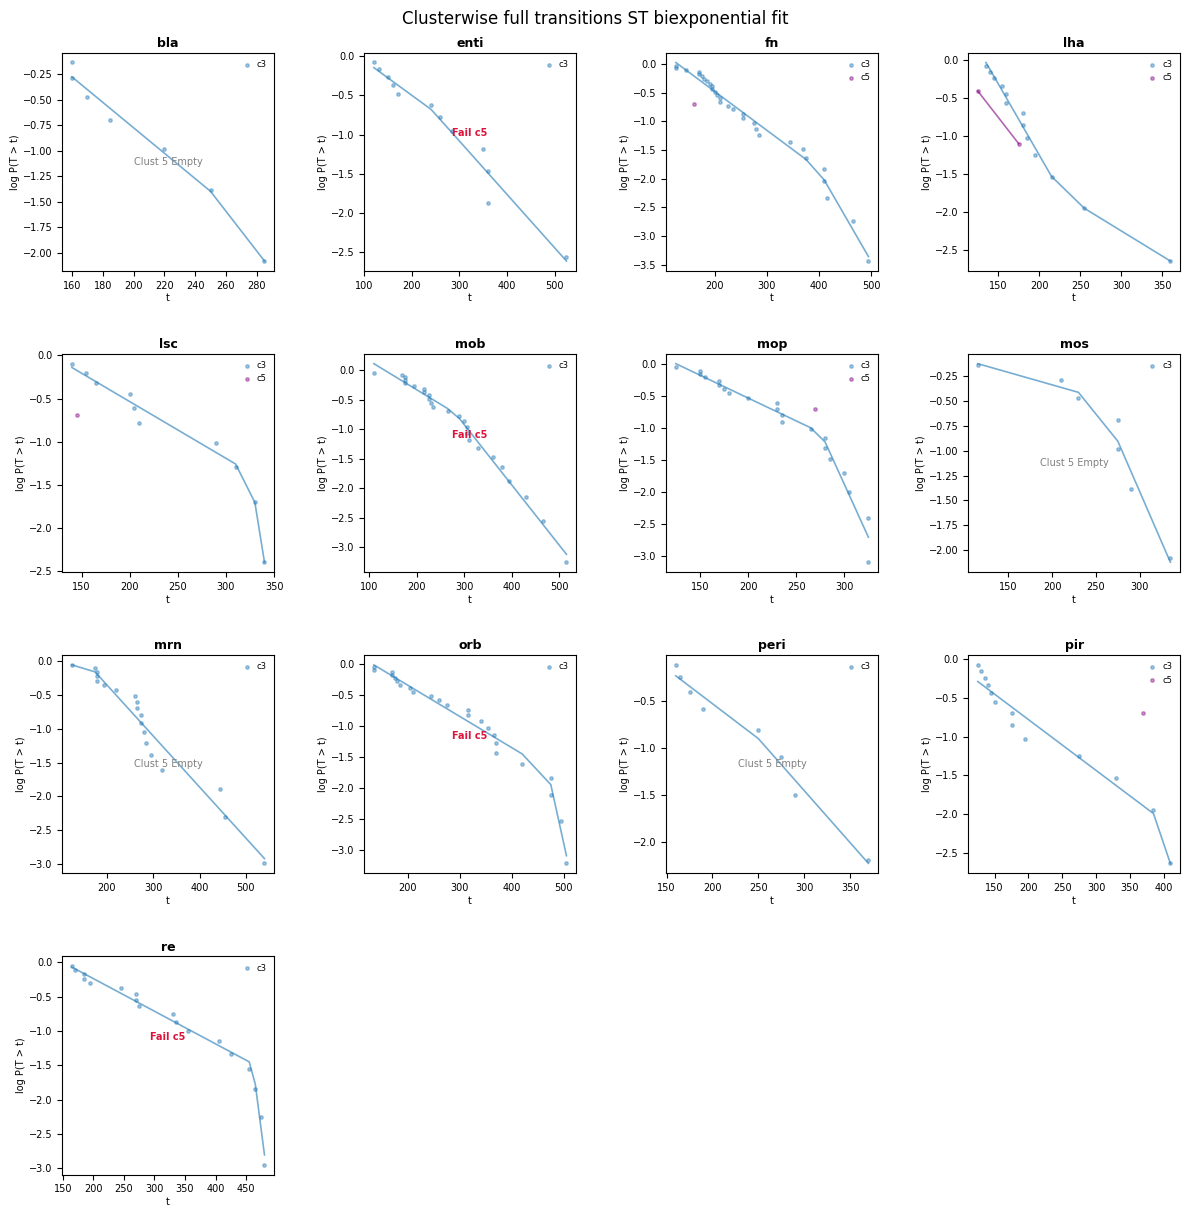

In [16]:
def plot_st_fit_on_axis(data, label, ax):
    """
    Plots ONLY the 'st' key data onto a single pre-allocated axis object.
    Clusters are remapped from 0-4 to 1-5 for labels and colors.
    """
    target_key = 'st'
    # Colors updated to map to keys 1 through 5
    colors = {1: 'green', 2: 'red', 3: 'C0', 4: 'orange', 5: 'purple'}
    last_break = None 
    
    # Clean, compact title for a 4x4 grid space
    ax.set_title(f"{label}", fontsize=9, fontweight='bold', pad=4)
    ax.set_ylabel("log P(T > t)", fontsize=7, labelpad=2)
    ax.set_xlabel("t", fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    
    # Loop over your cluster dictionaries (0, 1, 2, 3, 4)
    for i in data.keys():  
        plt_data = data[i][target_key]
        
        # Remap the cluster ID from 0-4 to 1-5 for color matching and labeling
        display_id = i + 1
        
        # Limit ST from 0 to 600 for full data
        plt_data = [x for x in plt_data if 0 < x < 600]
            
        # Check for emptiness
        if plt_data is None or len(plt_data) == 0:
            ax.text(0.5, 0.5, f"Clust {display_id} Empty", ha='center', va='center', 
                    transform=ax.transAxes, color='gray', fontsize=7)
            continue
            
        try:
            # Attempt fit
            l = fit_piecewiseLinear(plt_data)
            x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
            last_break = breaks
            
            # Pick color based on the remapped display_id (1-5)
            color = colors.get(display_id, "black")
            ax.scatter(x, y, color=color, alpha=0.4, s=6, label=f"c{display_id}")
            ax.plot(x, y_hat, color=color, alpha=0.6, linewidth=1.2)
            
            # Use a very small, unobtrusive legend for the tight layout
            ax.legend(fontsize=6, loc='upper right', frameon=False, handletextpad=0.2)
            
        except Exception as e:
            # Stack error strings using the 1-5 cluster mapping
            ax.text(0.5, 0.15 + (i * 0.12), f"Fail c{display_id}", 
                    ha='center', va='center', transform=ax.transAxes, 
                    color='crimson', fontsize=7, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_rows = 4
n_cols = 4

# Initialize a standard 4x4 figure matrix
fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = all_axes.flatten()

# Keep track of how many subplots we actually fill
idx = 0
for idx, f_full in enumerate(file_full):
    # If there are more than 16 files, break to prevent an IndexError
    if idx >= len(axes_flat):
        break
        
    network_label = f_full.split('_')[-1] 
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    # Pass the individual flattened axis index directly
    plot_st_fit_on_axis(pkl_full, network_label, axes_flat[idx])
    
    print(f"Processed ST Fit for: {network_label}")

# Hide any remaining unused panels if you have less than 16 networks
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Uniform, spacious padding so axes labels and titles don't collide
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.suptitle('Clusterwise full transitions ST biexponential fit', y=1.01)
plt.show()

Supplementary for full fpt fit

Processed FPT Fit for: bla
Processed FPT Fit for: enti
Processed FPT Fit for: fn
Processed FPT Fit for: lha
Processed FPT Fit for: lsc
Processed FPT Fit for: mob
Processed FPT Fit for: mop
Processed FPT Fit for: mos
Processed FPT Fit for: mrn
Processed FPT Fit for: orb
Processed FPT Fit for: peri
Processed FPT Fit for: pir
Processed FPT Fit for: re


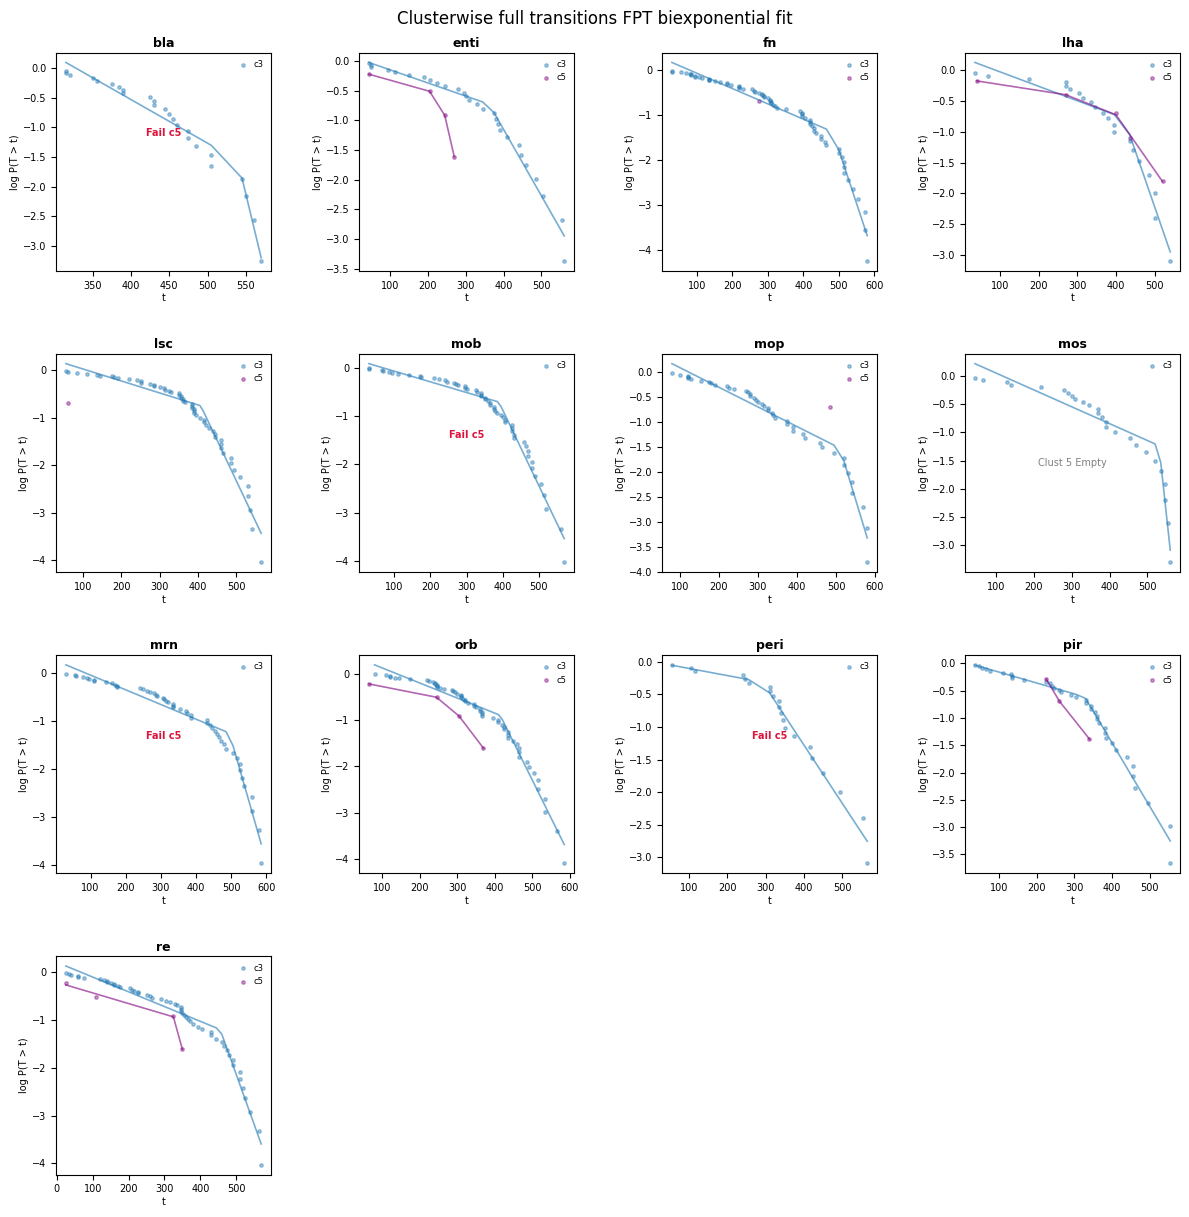

In [20]:

def plot_fpt_fit_on_axis(data, label, ax):
    """
    Plots ONLY the 'fpt' key data onto a single pre-allocated axis object.
    Clusters are remapped from 0-4 to 1-5 for labels and colors.
    """
    # TARGET KEY CHANGED TO FPT
    target_key = 'fpt' 
    colors = {1: 'green', 2: 'red', 3: 'C0', 4: 'orange', 5: 'purple'}
    last_break = None 
    
    # Clean, compact title for a 4x4 grid space
    ax.set_title(f"{label}", fontsize=9, fontweight='bold', pad=4)
    ax.set_ylabel("log P(T > t)", fontsize=7, labelpad=2)
    ax.set_xlabel("t", fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    
    # Loop over your cluster dictionaries (0, 1, 2, 3, 4)
    for i in data.keys():  
        plt_data = data[i][target_key]
        
        # Remap the cluster ID from 0-4 to 1-5 for color matching and labeling
        display_id = i + 1
        
        # Limit FPT values (Adjust limits here if needed based on your FPT distribution)
        plt_data = [x for x in plt_data if 0 < x < 600]
            
        # Check for emptiness
        if plt_data is None or len(plt_data) == 0:
            ax.text(0.5, 0.5, f"Clust {display_id} Empty", ha='center', va='center', 
                    transform=ax.transAxes, color='gray', fontsize=7)
            continue
            
        try:
            # Attempt fit
            l = fit_piecewiseLinear(plt_data)
            x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
            last_break = breaks
            
            # Pick color based on the remapped display_id (1-5)
            color = colors.get(display_id, "black")
            ax.scatter(x, y, color=color, alpha=0.4, s=6, label=f"c{display_id}")
            ax.plot(x, y_hat, color=color, alpha=0.6, linewidth=1.2)
            
            # Use a very small, unobtrusive legend for the tight layout
            ax.legend(fontsize=6, loc='upper right', frameon=False, handletextpad=0.2)
            
        except Exception as e:
            # Stack error strings using the 1-5 cluster mapping
            ax.text(0.5, 0.15 + (i * 0.12), f"Fail c{display_id}", 
                    ha='center', va='center', transform=ax.transAxes, 
                    color='crimson', fontsize=7, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_rows = 4
n_cols = 4

# Initialize a standard 4x4 figure matrix
fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = all_axes.flatten()

# Keep track of how many subplots we actually fill
idx = 0
for idx, f_full in enumerate(file_full):
    # If there are more than 16 files, break to prevent an IndexError
    if idx >= len(axes_flat):
        break
        
    network_label = f_full.split('_')[-1] 
    
    with open(f_full, "rb") as f:
        pkl_full = pickle.load(f)

    # Pass the individual flattened axis index directly to the FPT function
    plot_fpt_fit_on_axis(pkl_full, network_label, axes_flat[idx])
    
    print(f"Processed FPT Fit for: {network_label}")

# Hide any remaining unused panels if you have less than 16 networks
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Uniform, spacious padding so axes labels and titles don't collide
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.suptitle('Clusterwise full transitions FPT biexponential fit', y=1.01)
plt.show()

PArt FPT clusterwise fit

Processed Partial FPT Fit for: part_bla
Processed Partial FPT Fit for: part_enti
Processed Partial FPT Fit for: part_fn
Processed Partial FPT Fit for: part_lha
Processed Partial FPT Fit for: part_lsc
Processed Partial FPT Fit for: part_mob
Processed Partial FPT Fit for: part_mop
Processed Partial FPT Fit for: part_mos
Processed Partial FPT Fit for: part_mrn
Processed Partial FPT Fit for: part_orb
Processed Partial FPT Fit for: part_peri
Processed Partial FPT Fit for: part_pir
Processed Partial FPT Fit for: part_re


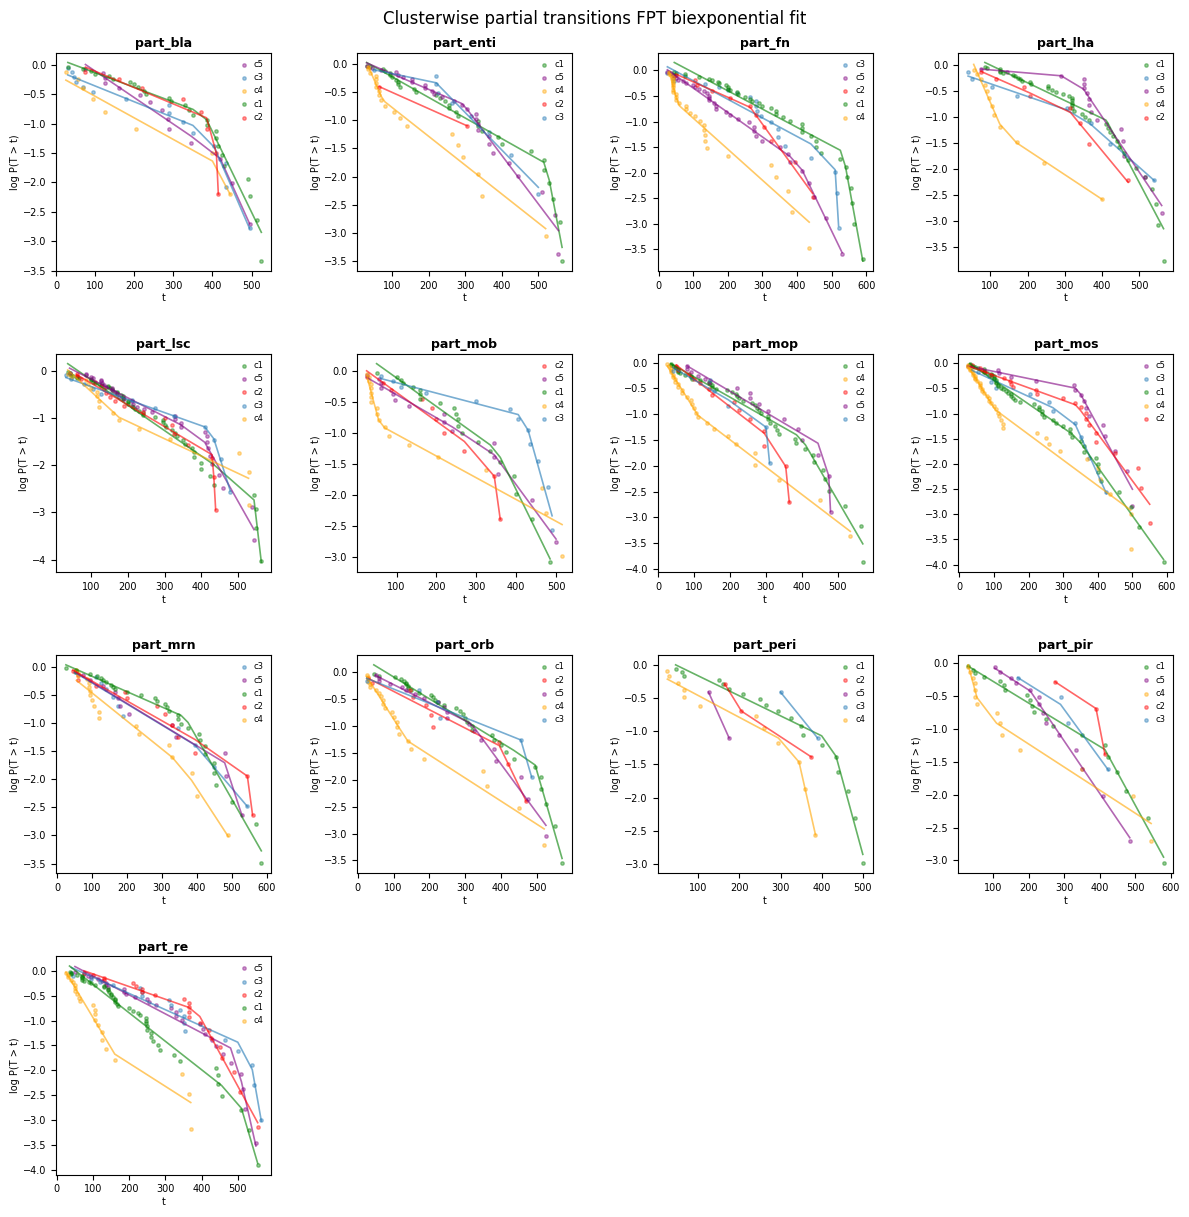

In [21]:
def plot_part_fpt_fit_on_axis(data, label, ax):
    """
    Plots ONLY the 'fpt' key data for partial files onto a single axis object.
    Clusters are remapped from 0-4 to 1-5 for labels and colors.
    """
    # Target key remains 'fpt'
    target_key = 'fpt' 
    colors = {1: 'green', 2: 'red', 3: 'C0', 4: 'orange', 5: 'purple'}
    last_break = None 
    
    # Clean, compact title configuration for 4x4 matrix
    ax.set_title(f"{label}", fontsize=9, fontweight='bold', pad=4)
    ax.set_ylabel("log P(T > t)", fontsize=7, labelpad=2)
    ax.set_xlabel("t", fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    
    # Loop over cluster dictionaries (0, 1, 2, 3, 4)
    for i in data.keys():  
        plt_data = data[i][target_key]
        
        # Remap cluster IDs from 0-4 to 1-5
        display_id = i + 1
        
        # Limit FPT values for partial data (Keeping 0 < x < 600)
        plt_data = [x for x in plt_data if 0 < x < 600]
            
        # Check for emptiness
        if plt_data is None or len(plt_data) == 0:
            ax.text(0.5, 0.5, f"Clust {display_id} Empty", ha='center', va='center', 
                    transform=ax.transAxes, color='gray', fontsize=7)
            continue
            
        try:
            # Attempt piecewise linear fit
            l = fit_piecewiseLinear(plt_data)
            x, y, y_hat, breaks = l[0], l[1], l[2], round(l[3])
            last_break = breaks
            
            # Scatter plot and fit line execution
            color = colors.get(display_id, "black")
            ax.scatter(x, y, color=color, alpha=0.4, s=6, label=f"c{display_id}")
            ax.plot(x, y_hat, color=color, alpha=0.6, linewidth=1.2)
            
            # Compact legend spacing
            ax.legend(fontsize=6, loc='upper right', frameon=False, handletextpad=0.2)
            
        except Exception as e:
            # Stack failures sequentially down the subplot space
            ax.text(0.5, 0.15 + (i * 0.12), f"Fail c{display_id}", 
                    ha='center', va='center', transform=ax.transAxes, 
                    color='crimson', fontsize=7, weight='semibold')
                
    return last_break


# --- Main Execution Section ---

n_rows = 4
n_cols = 4

# Initialize a standard 4x4 figure matrix (12x12 inches canvas scale)
fig, all_axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = all_axes.flatten()

# Keep track of how many subplots we actually fill
idx = 0
for idx, f_part in enumerate(file_part):
    # Prevent index crashes if file count goes beyond 16 available frames
    if idx >= len(axes_flat):
        break
        
    # Extracted network label prefixed with "part_"
    network_label = f"part_{f_part.split('_')[-1]}" 
    
    # UNCOMMENTED AND UPDATED: Read pkl_part from file_part paths
    with open(f_part, "rb") as f:
        pkl_part = pickle.load(f)

    # Pass individual axis to the partial FPT function
    plot_part_fpt_fit_on_axis(pkl_part, network_label, axes_flat[idx])
    
    print(f"Processed Partial FPT Fit for: {network_label}")

# Wipe clean any unused subplot boxes left over in the 4x4 matrix frame
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Apply compact grid margin parameters
plt.tight_layout(h_pad=2.5, w_pad=2.5)
plt.suptitle('Clusterwise partial transitions FPT biexponential fit', y=1.01)
plt.show()